## Importing Required Libraries

In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Image Loading
def load_images (left_path, right_path, resize_match = True):
    
    left = cv2.imread(left_path)
    right = cv2.imread(right_path)
    
    if left is None or right is None:
        raise ValueError("Either or both images failed to load.")
    
    # If they don't match, resize the second to match the first
    if resize_match and left.shape != right.shape:
        h,w= left.shape[:2]
        right = cv2.resize(right, (w,h), interpolation=cv2.INTER_AREA)
        
    return left, right

def show_images(images, titles, cmap=None, figsize=(12,6)):
    fig, ax = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        ax = [ax]

    for i in range(len(images)):
        ax[i].imshow(images[i], cmap=cmap)
        ax[i].set_title(titles[i])
        ax[i].axis('off')

    plt.tight_layout()
    plt.show()

# Alignment (Image Registration)    
def align_images(target_img, moving_img, max_features=1000):
    # 1. Detect ORB features and descriptors
    orb = cv2.ORB_create(max_features)
    kp1, des1 = orb.detectAndCompute(target_img, None)
    kp2, des2 = orb.detectAndCompute(moving_img, None)

    # 2. Match features using Brute-Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    
    # 3. Extract location of good matches
    points1 = np.zeros((len(matches), 2), dtype=np.float32)
    points2 = np.zeros((len(matches), 2), dtype=np.float32)

    for i, match in enumerate(matches):
        points1[i] = kp1[match.queryIdx].pt
        points2[i] = kp2[match.trainIdx].pt
        
    # 4. Find Homography matrix
    H, mask = cv2.findHomography(points2, points1, cv2.RANSAC)
    
    # 5. Use homography to warp image
    h, w = target_img.shape[:2]
    aligned = cv2.warpPerspective(moving_img, H, (w, h))

    return aligned

# Grayscale
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Alignment Quality
def alignment_difference(img1_gray, img2_gray):

    diff = cv2.absdiff(img1_gray, img2_gray)

    plt.figure(figsize=(6, 6))
    plt.imshow(diff, cmap='gray')
    plt.title("Alignment Quality (Abs Diff)")
    plt.axis('off')
    plt.show()

    return diff
# SHIFT ESTIMATOR
# Disparity
def compute_disparity(left_gray, right_gray):

    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=16 * 4,
        blockSize=5,

        P1=8 * 3 * 5**2,    # Penalty for small changes.
        P2=32 * 3 * 5**2,   # Penalty for large changes.

        disp12MaxDiff=1,
        uniquenessRatio=10,

        speckleWindowSize=100,
        speckleRange=32
    )

    disparity = stereo.compute(left_gray, right_gray)

    return disparity

# Depth Normalizer
def normalize_depth(disparity):

    disparity = disparity.copy()
    # 1. Handle invalid pixels 
    # OpenCV often marks pixels it couldn't match with -16 or -1
    disparity[disparity < 0] = 0
    
    # 2. Normalize to 0-255
    # We use CV_8U to ensure it's compatible with standard image formats
    normalized = cv2.normalize(
        disparity,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX,
        dtype=cv2.CV_8U
    )

    return normalized

# Color Map
def apply_heatmap(depth_map, colormap=cv2.COLORMAP_JET):

    return cv2.applyColorMap(depth_map, colormap)

def save_image(image, filename, folder="output"):

    if not os.path.exists(folder):
        os.makedirs(folder)

    path = os.path.join(folder, filename)

    cv2.imwrite(path, image)

    print(f"Success: Image Saved to {path}")
    
def stereo_depth_pipeline(left_path, right_path):

    # Load
    left, right = load_images(left_path, right_path)

    # RGB visualization
    left_rgb = cv2.cvtColor(left, cv2.COLOR_BGR2RGB)
    right_rgb = cv2.cvtColor(right, cv2.COLOR_BGR2RGB)

    show_images(
        [left_rgb, right_rgb],
        ["Left Image", "Right Image"]
    )

    # Align
    right_aligned = align_images(left, right)

    # Gray
    left_gray = to_gray(left)
    right_gray = to_gray(right_aligned)

    show_images(
        [left_gray, right_gray],
        ["Left Gray", "Right Gray"],
        cmap='gray'
    )

    # Alignment check
    alignment_difference(left_gray, right_gray)

    # Disparity
    disparity = compute_disparity(left_gray, right_gray)

    # Normalize
    depth_map = normalize_depth(disparity)

    # Heatmap
    heatmap = apply_heatmap(depth_map)

    # Show results
    show_images(
        [depth_map, heatmap],
        ["Depth Map", "Heatmap"]
    )

    # Save
    save_image(depth_map, "depth_map.png")
    save_image(heatmap, "heatmap.png")

    return depth_map, heatmap

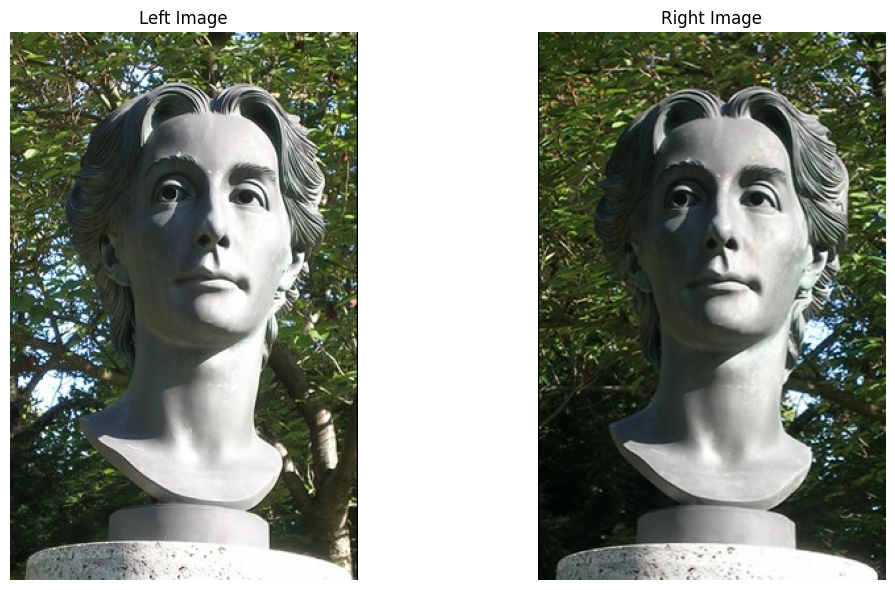

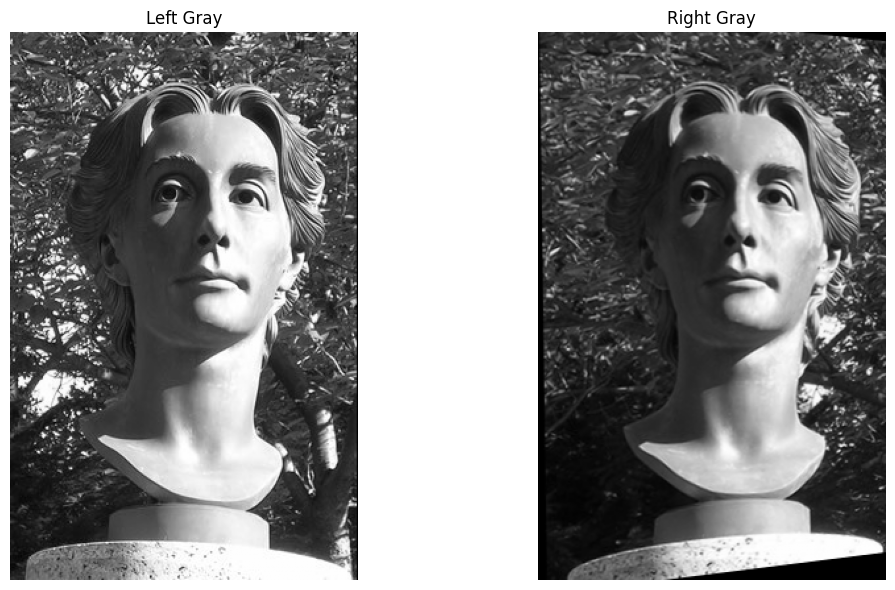

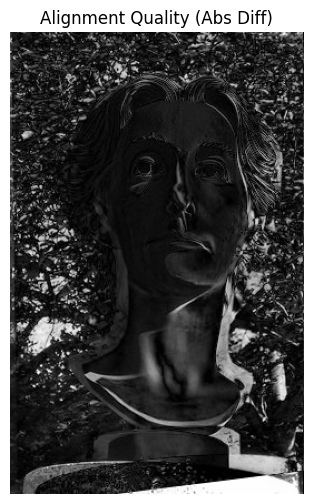

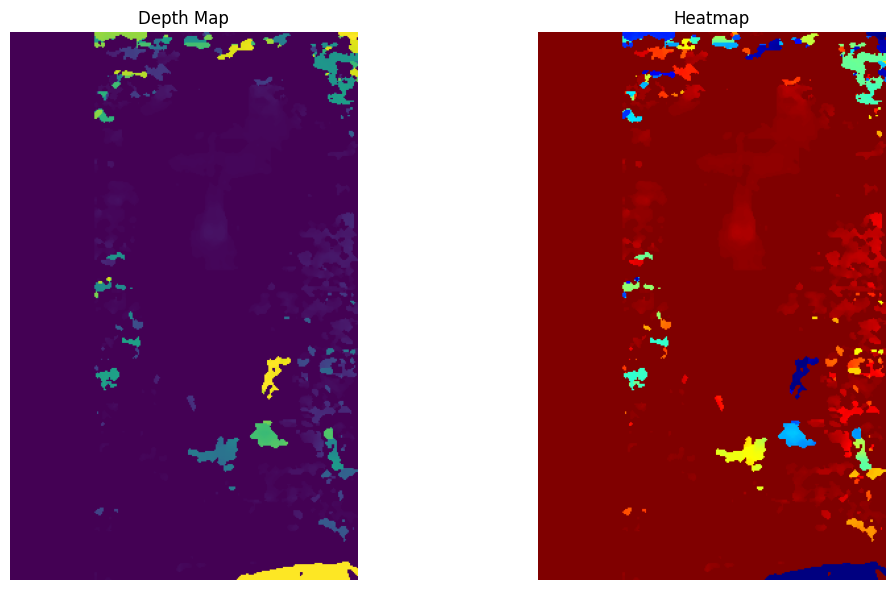

Success: Image Saved to output\depth_map.png
Success: Image Saved to output\heatmap.png


In [10]:
depth_map, heatmap = stereo_depth_pipeline(
    r"Kiro's Images\Left.jpg",
    r"Kiro's Images\Right.jpg"
)